In [1]:
import tempfile
import pickle
import sys
import traceback
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from pprint import pprint

from one.api import ONE
from scipy.special import logit, softmax
import os
from os.path import join
import pickle as pkl
from brainwidemap.bwm_loading import bwm_query, bwm_units, load_trials_and_mask, merge_probes

import concurrent.futures
import numpy as np
import pandas as pd
from pathlib import Path
import pickle
import sys

from one.api import ONE
from brainbox.io.one import SessionLoader
from iblatlas.atlas import BrainRegions
from sklearn.metrics import balanced_accuracy_score

from brainwidemap.bwm_loading import (
    bwm_query,
    load_good_units,
    load_trials_and_mask,
    merge_probes,
    bwm_units,
)

from glob import glob
from sklearn.decomposition import PCA
import warnings
from sklearn.metrics.pairwise import cosine_similarity
warnings.filterwarnings("ignore")

In [2]:
regions_of_interest = np.asarray([
    "ACB",
    "IRN",
    "CA1",
    "SUV",
    "LSr",
    "DG",
    "PO",
    "CP",
    "APN",
    "SCm",
    "GRN",
    "SIM",
    "MG",
    "ACAd",
    "ZI",
    "VISa",
    "MRN",
    "VPL",
    "MD",
    "POL",
    "PARN",
    "SSp-bfd",
    "MV",
    "LP",
    "LGd",
    "RN",
    "SSs",
    "CA3",
    "PAG",
    "SI",
    "VPM",
    "PRNr",
    "PoT",
    "IP",
    "CENT3",
    "MOp",
    "LD",
    "RT",
    "PPN",
])

In [3]:
# engagement, let's just do behavioral analysis.


In [4]:
trajectories = glob('../data/generated/manifold/true_results_congruence/*.pkl')
engagement_trajectories = glob('../data/generated/manifold/engagement/*.pkl')

In [5]:
# no, pca separately
# plot


def get_aligned_trajectory_data(data_true, data_engagement):
    
    shared_keys = sorted([k for k in data_true.keys() if k in data_engagement.keys()])     
    true_list = []
    for k in shared_keys:
        true_list.append(data_true[k])
        
    stiched_true = np.concatenate(true_list, axis=0)
    stiched_true = np.nan_to_num(stiched_true) 
    
    pca = PCA(n_components=3)
    true_pca_session = pca.fit_transform(stiched_true.T) 

    real_data = np.asarray([
        true_pca_session[0:50, :],
        true_pca_session[50:100, :],
        true_pca_session[100:150, :],
        true_pca_session[150:, :]
    ])


    engagement_list = []
    for k in shared_keys:
        engagement_list.append(data_engagement[k])
        
    stiched_engagement = np.concatenate(engagement_list, axis=0)
    stiched_engagement = np.nan_to_num(stiched_engagement)
        
    engagement_pca_session = pca.fit_transform(stiched_engagement.T)
    
    cond_data = np.asarray([
            engagement_pca_session[0:50, :],
            engagement_pca_session[50:100, :],
            engagement_pca_session[100:150, :],
            engagement_pca_session[150:, :]
    ])

        
    return real_data, cond_data

In [6]:
def plot_trajectories_on_ax(ax1, ax2,traj_A, traj_B, traj_C, traj_D, title):
    conditions = [
        (traj_A, 'blue',   'Incongruent correct'),
        (traj_B, 'red',    'Incongruent incorrect'),
        (traj_C, 'green',  'Incongruent engaged'),
        (traj_D, 'purple', 'Incongruent disengaged')
    ]

    for traj, color, label in conditions:
        if label=='Incongruent correct' or  label=='Incongruent incorrect':
            ax=ax1
        else:
            ax=ax2
        ax.plot(traj[:, 0], traj[:, 1], traj[:, 2], 
                color=color, label=label, linewidth=1.5, marker='o', markersize=3)
        ax.scatter(traj[0, 0], traj[0, 1], traj[0, 2], color=color, s=80, edgecolor='black', zorder=5)
        ax.scatter(traj[-1, 0], traj[-1, 1], traj[-1, 2], color=color, s=80, edgecolor='black', zorder=5, marker='*')
    for ax in [ax1, ax2]:
        ax.set_title(title)
        ax.set_xlabel("PC 1")
        ax.set_ylabel("PC 2")
        ax.set_zlabel("PC 3")
        ax.legend()

In [7]:
def plot_trajectories(ax1,traj_A, traj_B, traj_C, traj_D, title):
    conditions = [
        (traj_A, 'blue',   'Congruent engaged'),
        (traj_B, 'red',    'Congruent disengaged'),
        (traj_C, 'green',  'Incongruent engaged'),
        (traj_D, 'purple', 'Incongruent disengaged')
    ]

    for traj, color, label in conditions:
        ax1.plot(traj[:, 0], traj[:, 1], traj[:, 2], 
                color=color, label=label, linewidth=1.5, marker='o', markersize=3)
        ax1.scatter(traj[0, 0], traj[0, 1], traj[0, 2], color=color, s=80, edgecolor='black', zorder=5)
        ax1.scatter(traj[-1, 0], traj[-1, 1], traj[-1, 2], color=color, s=80, edgecolor='black', zorder=5, marker='*')
    for ax in [ax1]:
        ax.set_title(title)
        ax.set_xlabel("PC 1")
        ax.set_ylabel("PC 2")
        ax.set_zlabel("PC 3")
        ax.legend()

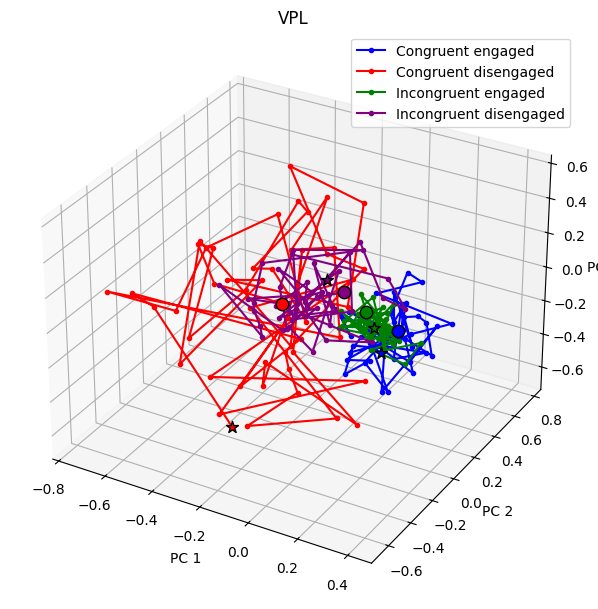

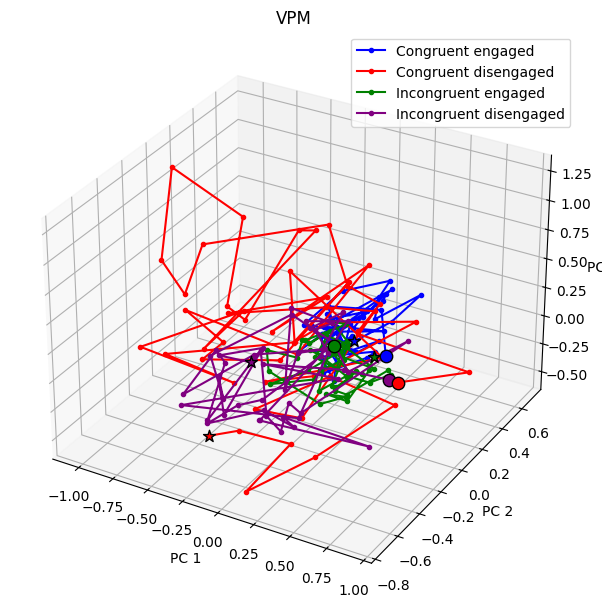

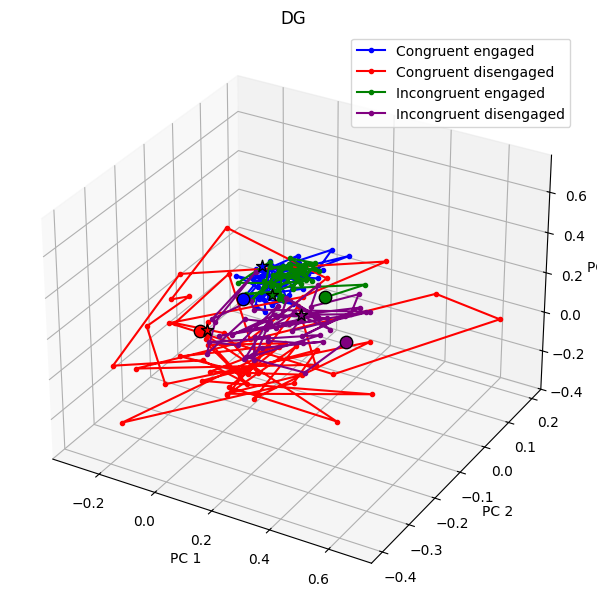

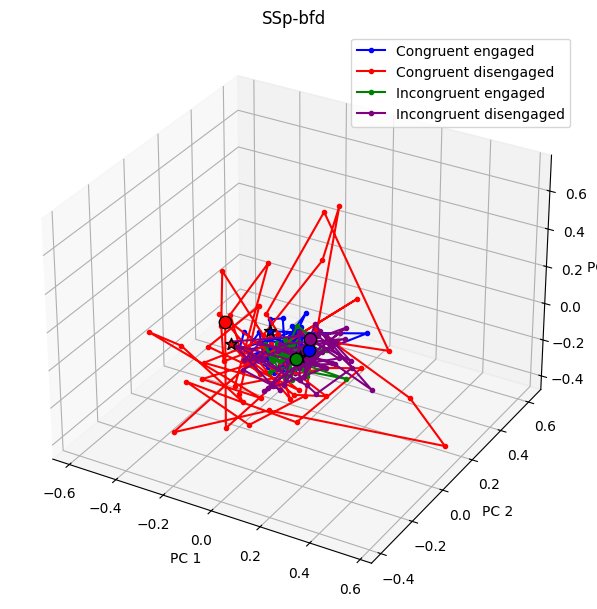

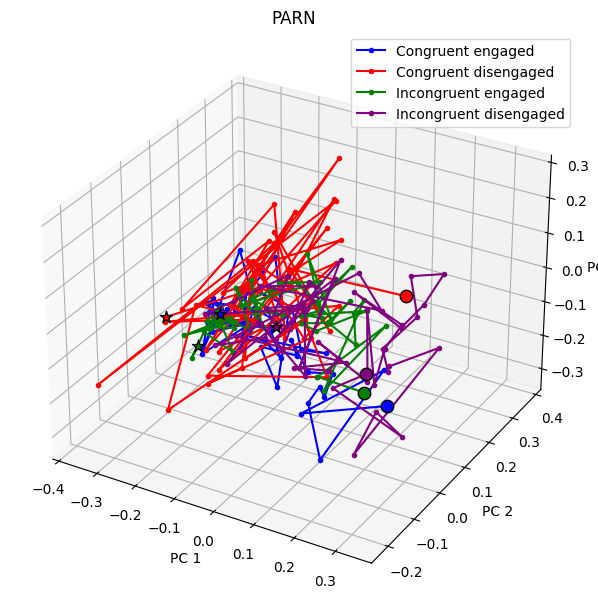

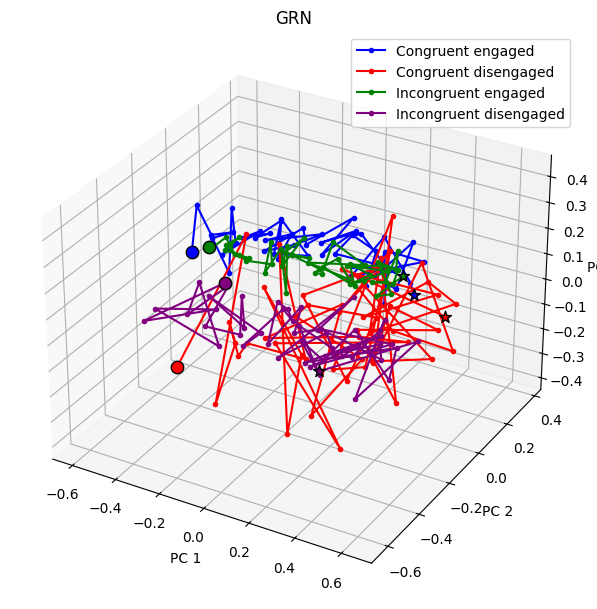

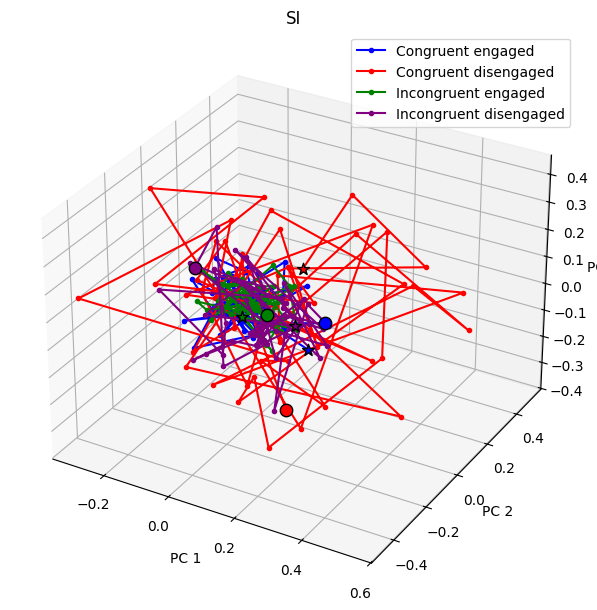

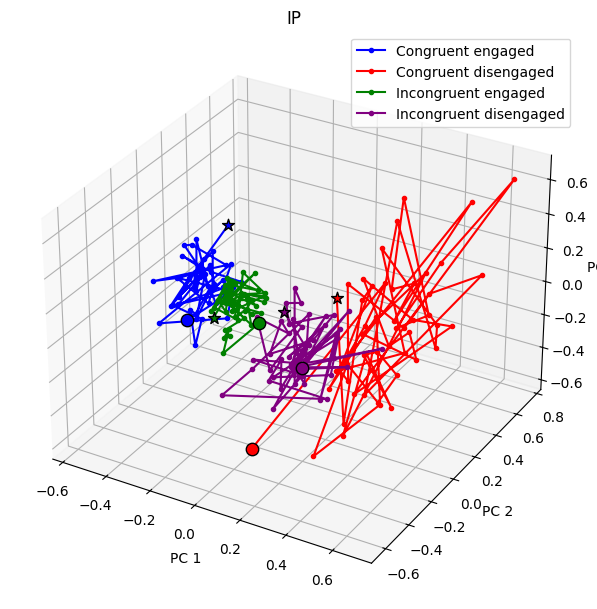

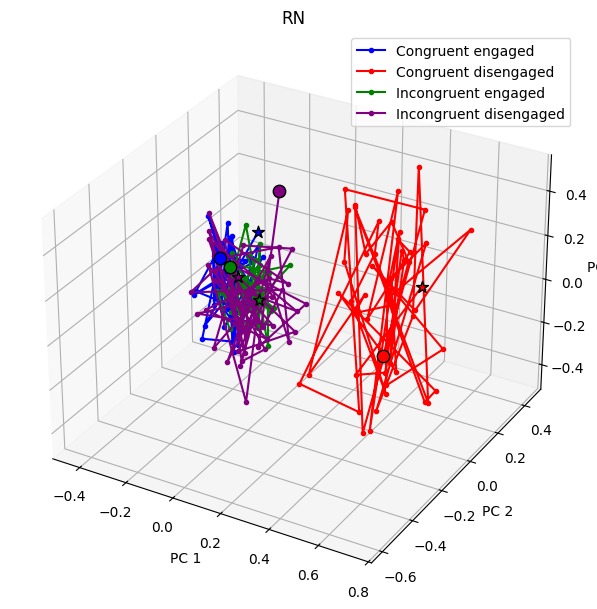

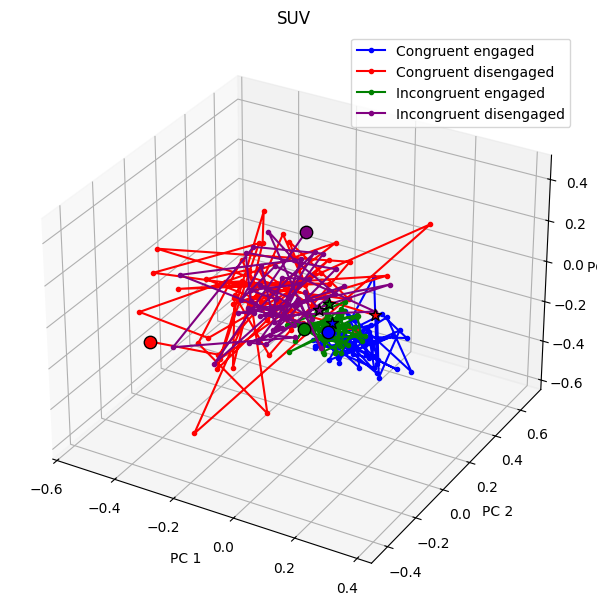

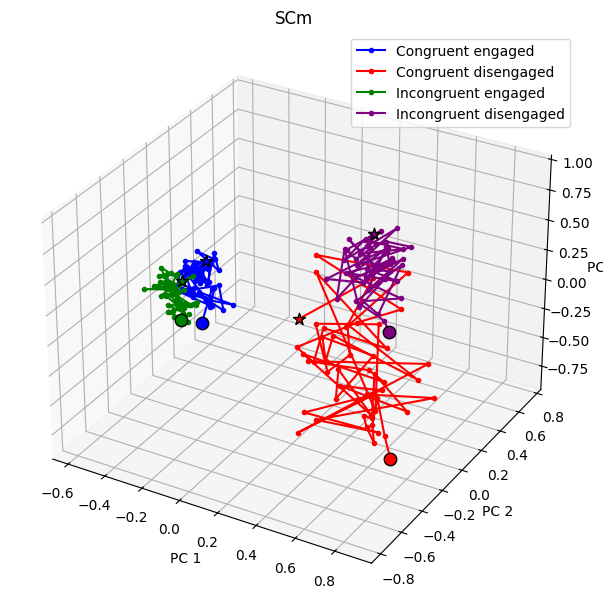

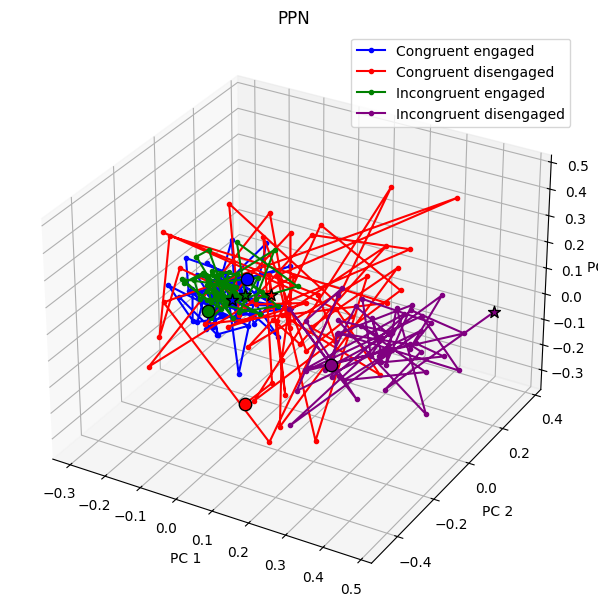

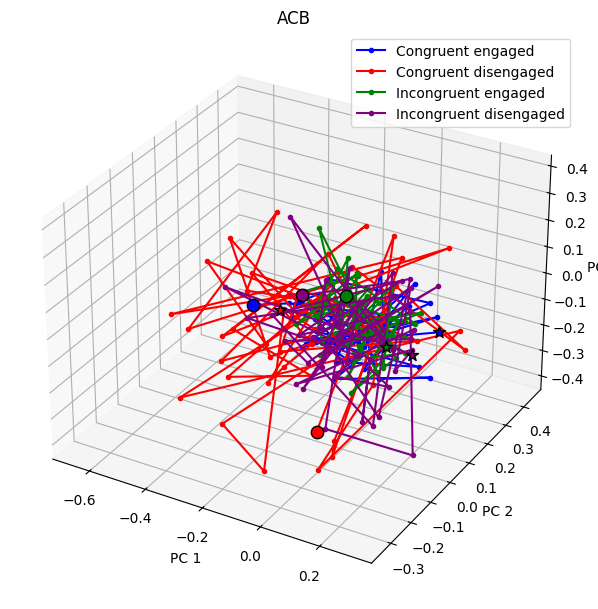

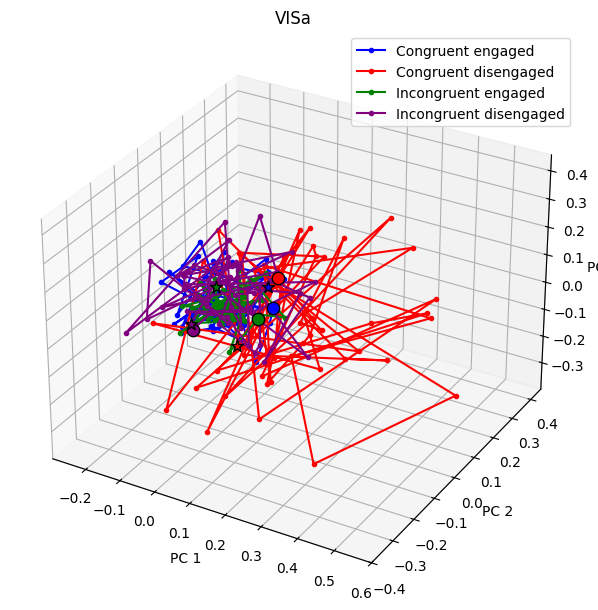

need at least one array to concatenate SSs


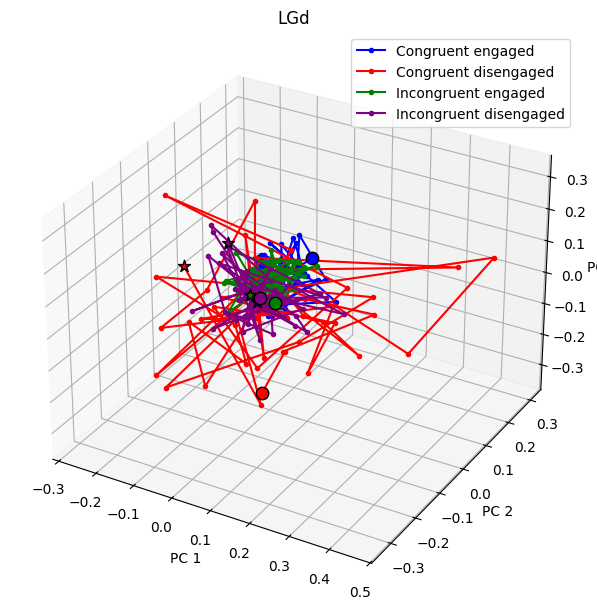

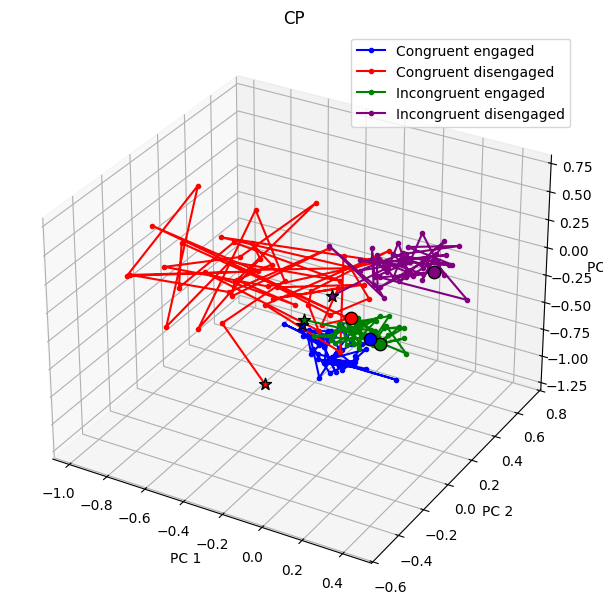

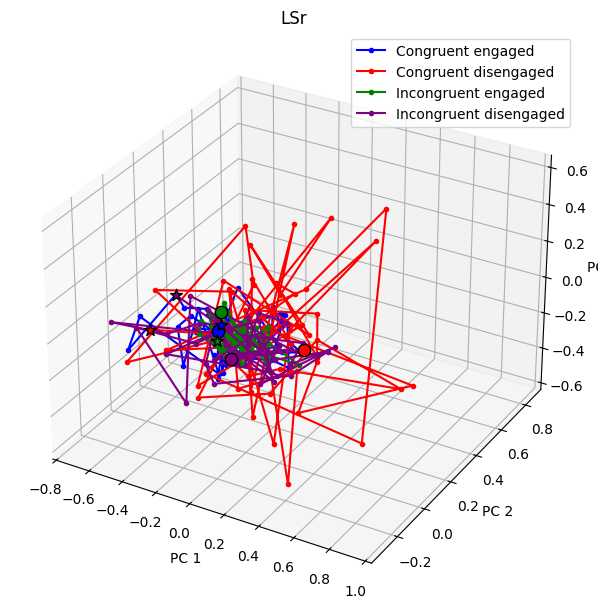

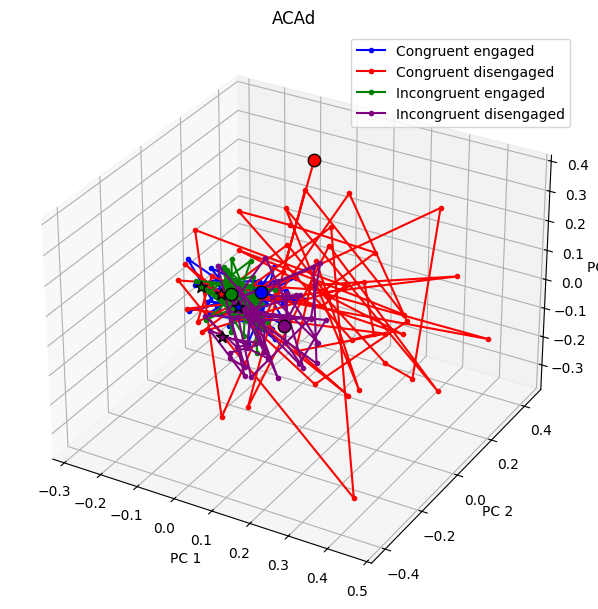

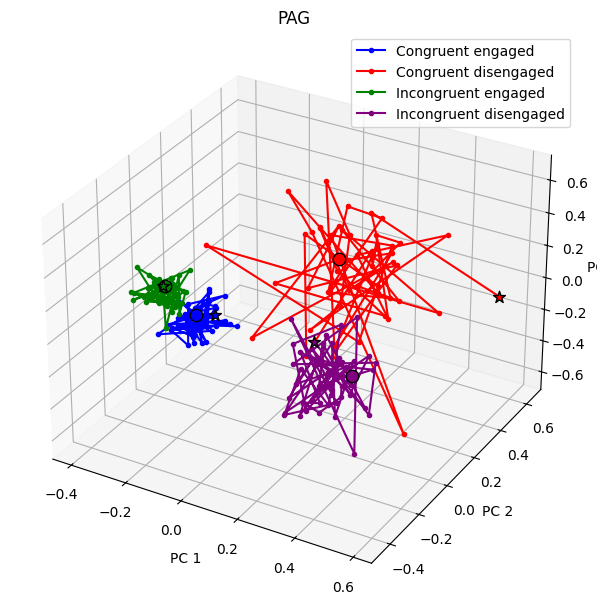

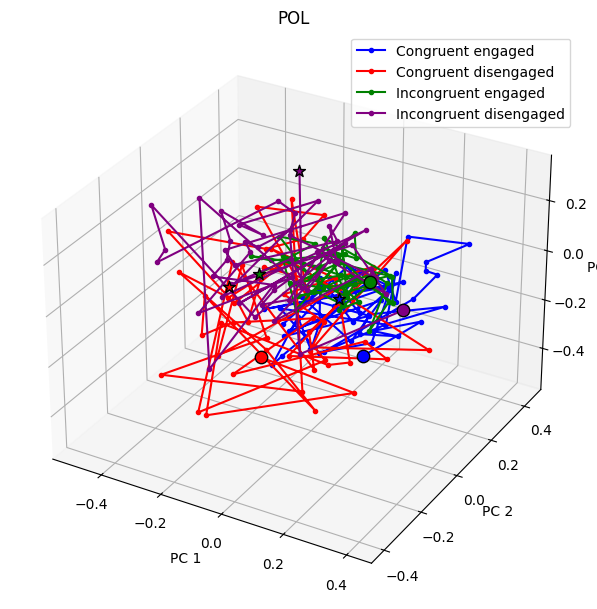

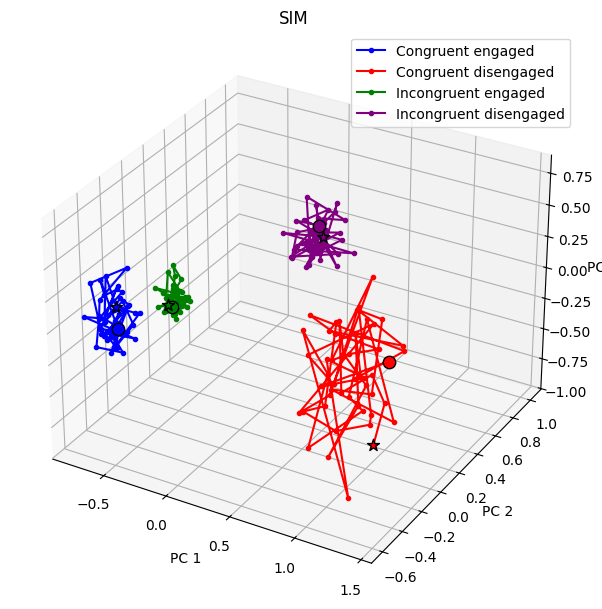

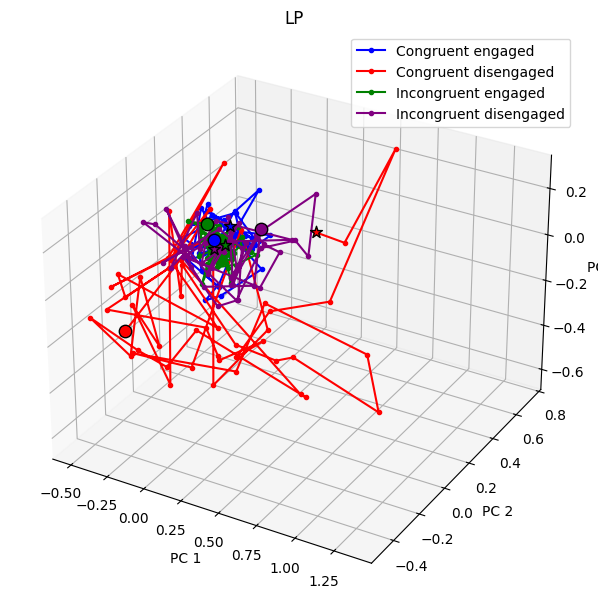

[Errno 2] No such file or directory: '../data/generated/manifold/engagement/aggregated_PoT_engagement_True.pkl' PoT


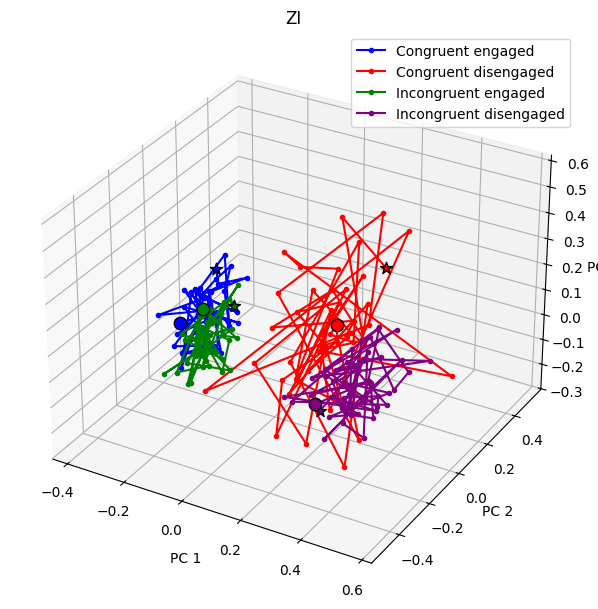

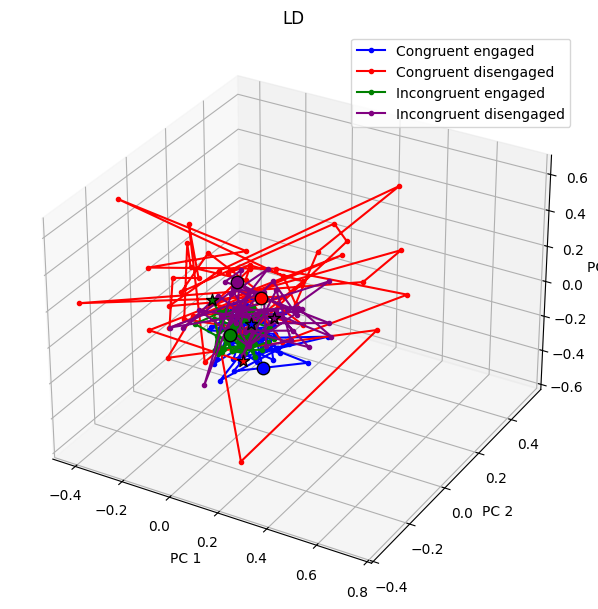

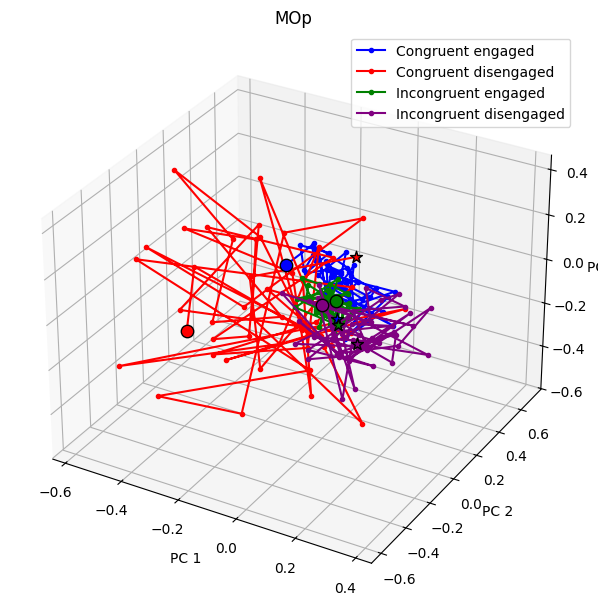

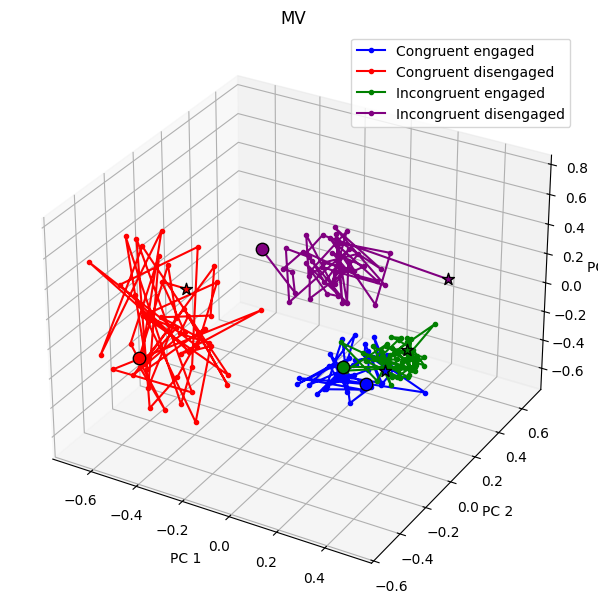

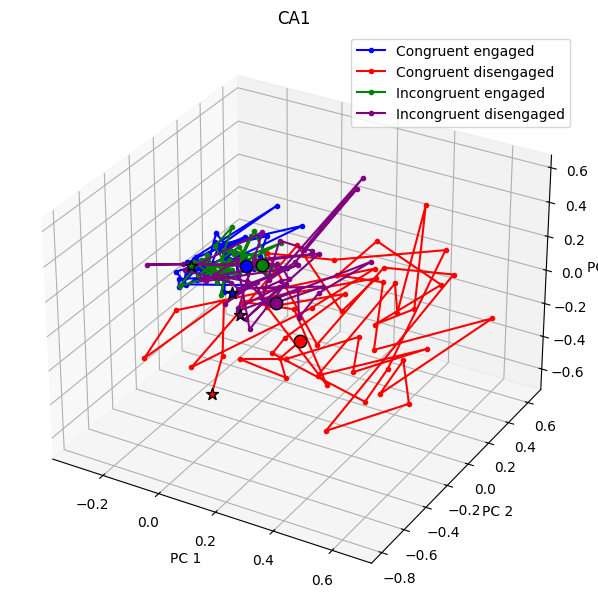

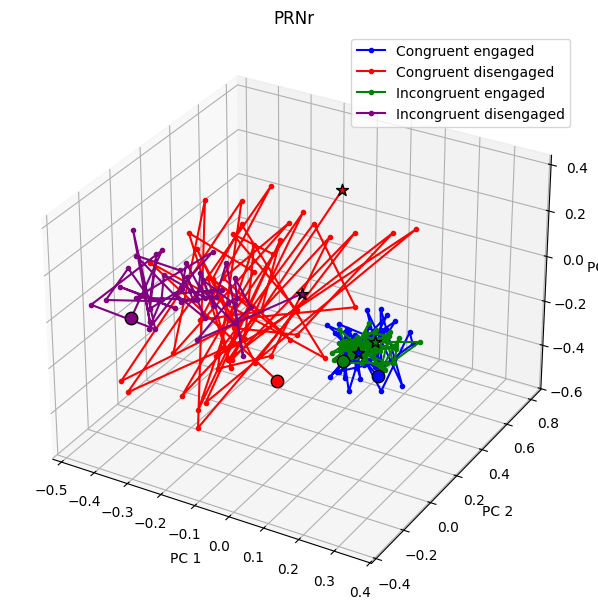

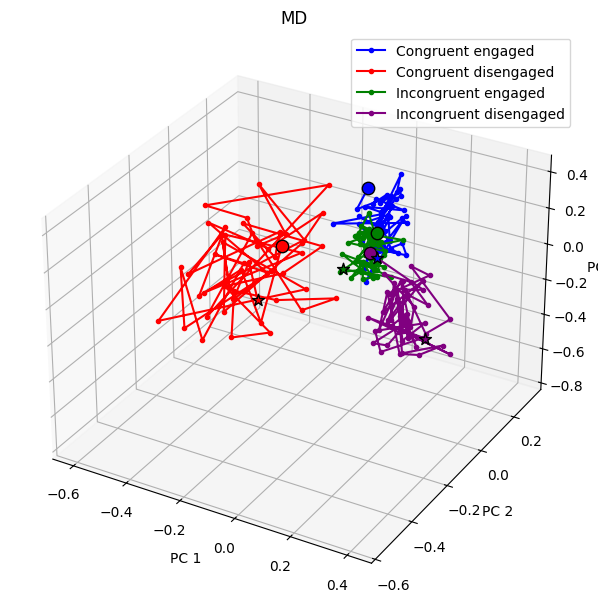

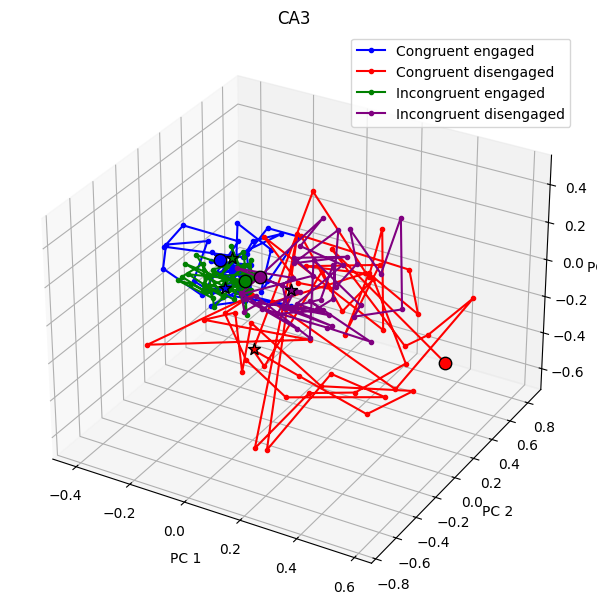

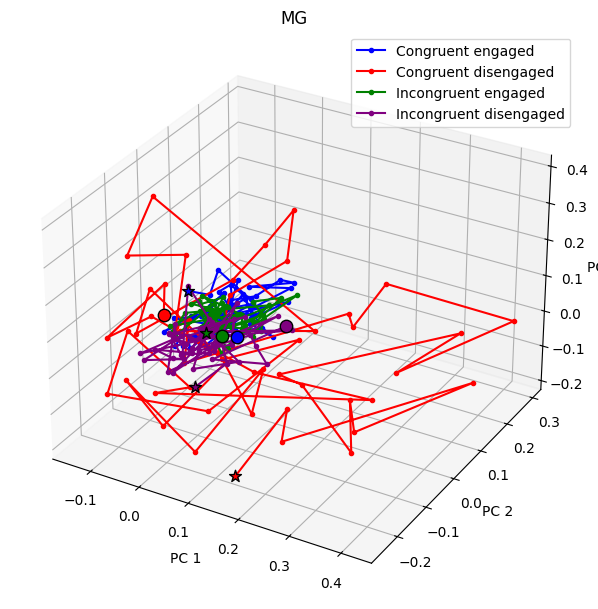

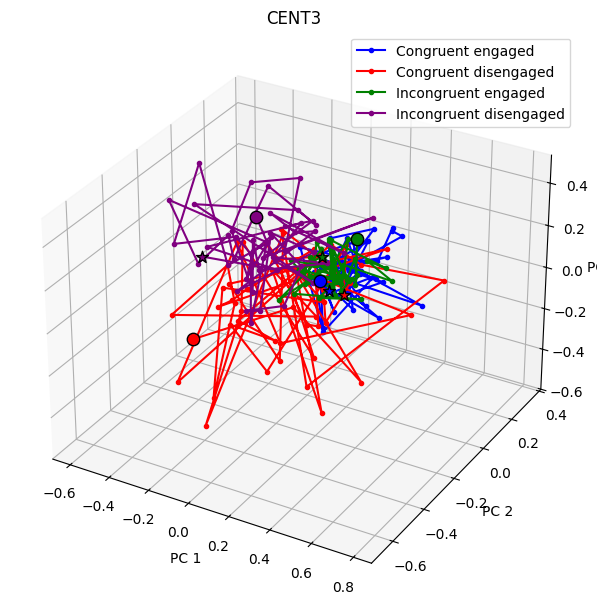

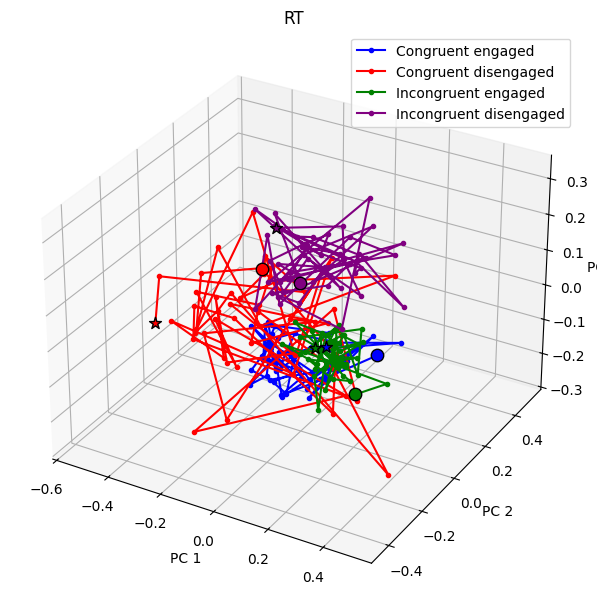

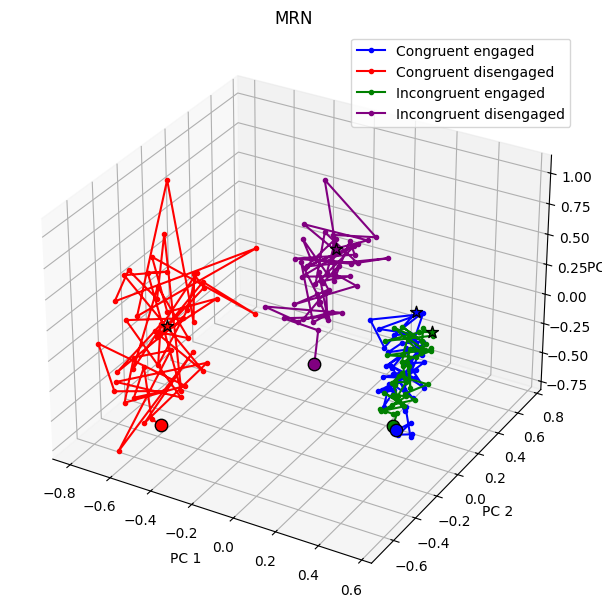

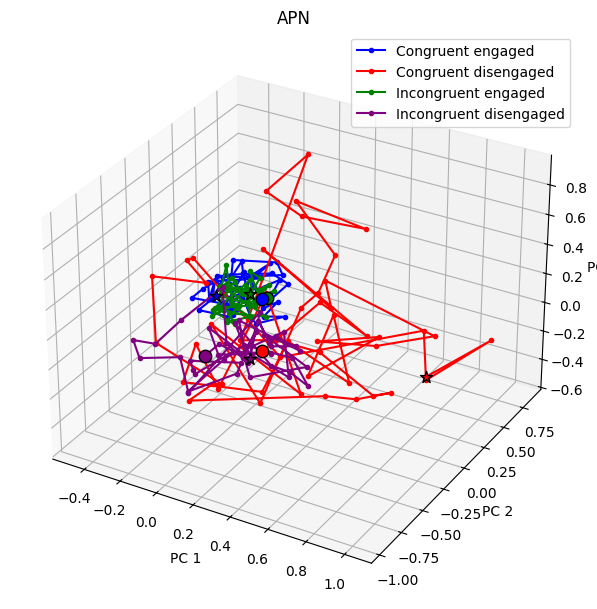

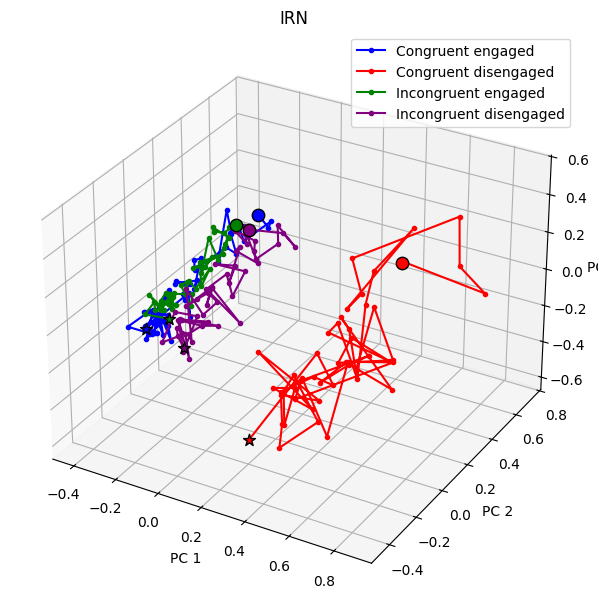

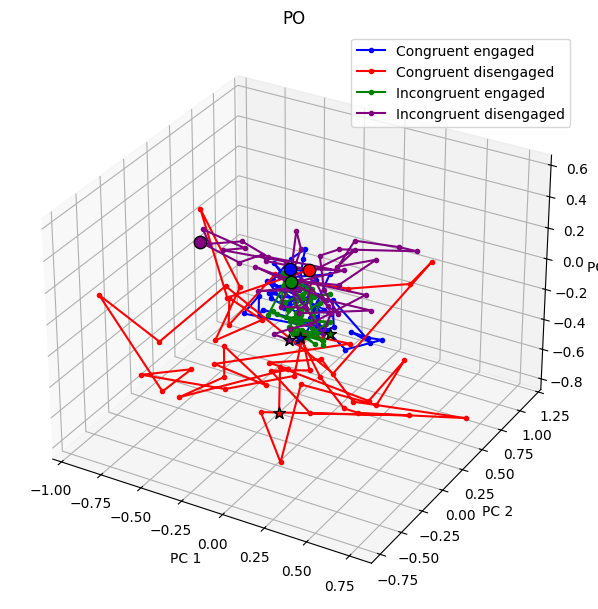

In [8]:
for fname in trajectories:

    try:
        rname = fname.rsplit("/")[-1].rsplit(".pkl")[0].rsplit("_")[1]
        if rname in regions_of_interest:
            engagement_fname = f"../data/generated/manifold/engagement/aggregated_{rname}_engagement_True.pkl"
            d_engagement = pkl.load(open(engagement_fname,'rb'))
            d_true = pkl.load(open(fname,'rb'))
            
            real_data, null_data = get_aligned_trajectory_data(d_true, d_engagement)
            
        
            fig = plt.figure(figsize=(12, 6))
            ax1 = fig.add_subplot(1, 2, 1, projection='3d')
            # ax2 = fig.add_subplot(1, 2, 2, projection='3d')
            # plot_trajectories_on_ax(ax1, ax2, real_data[2,:], real_data[3,:], null_data[2,:], null_data[3,:], f'{rname}')
            plot_trajectories(ax1,null_data[0,:], null_data[1,:], null_data[2,:], null_data[3,:], f'{rname}')
            plt.tight_layout()
            plt.show()
    except Exception as e:
        print(e, rname)